In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import urllib.request
import warnings

warnings.filterwarnings('ignore')

font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Bold.ttf"
font_path = "NanumGothic-Bold.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

f_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

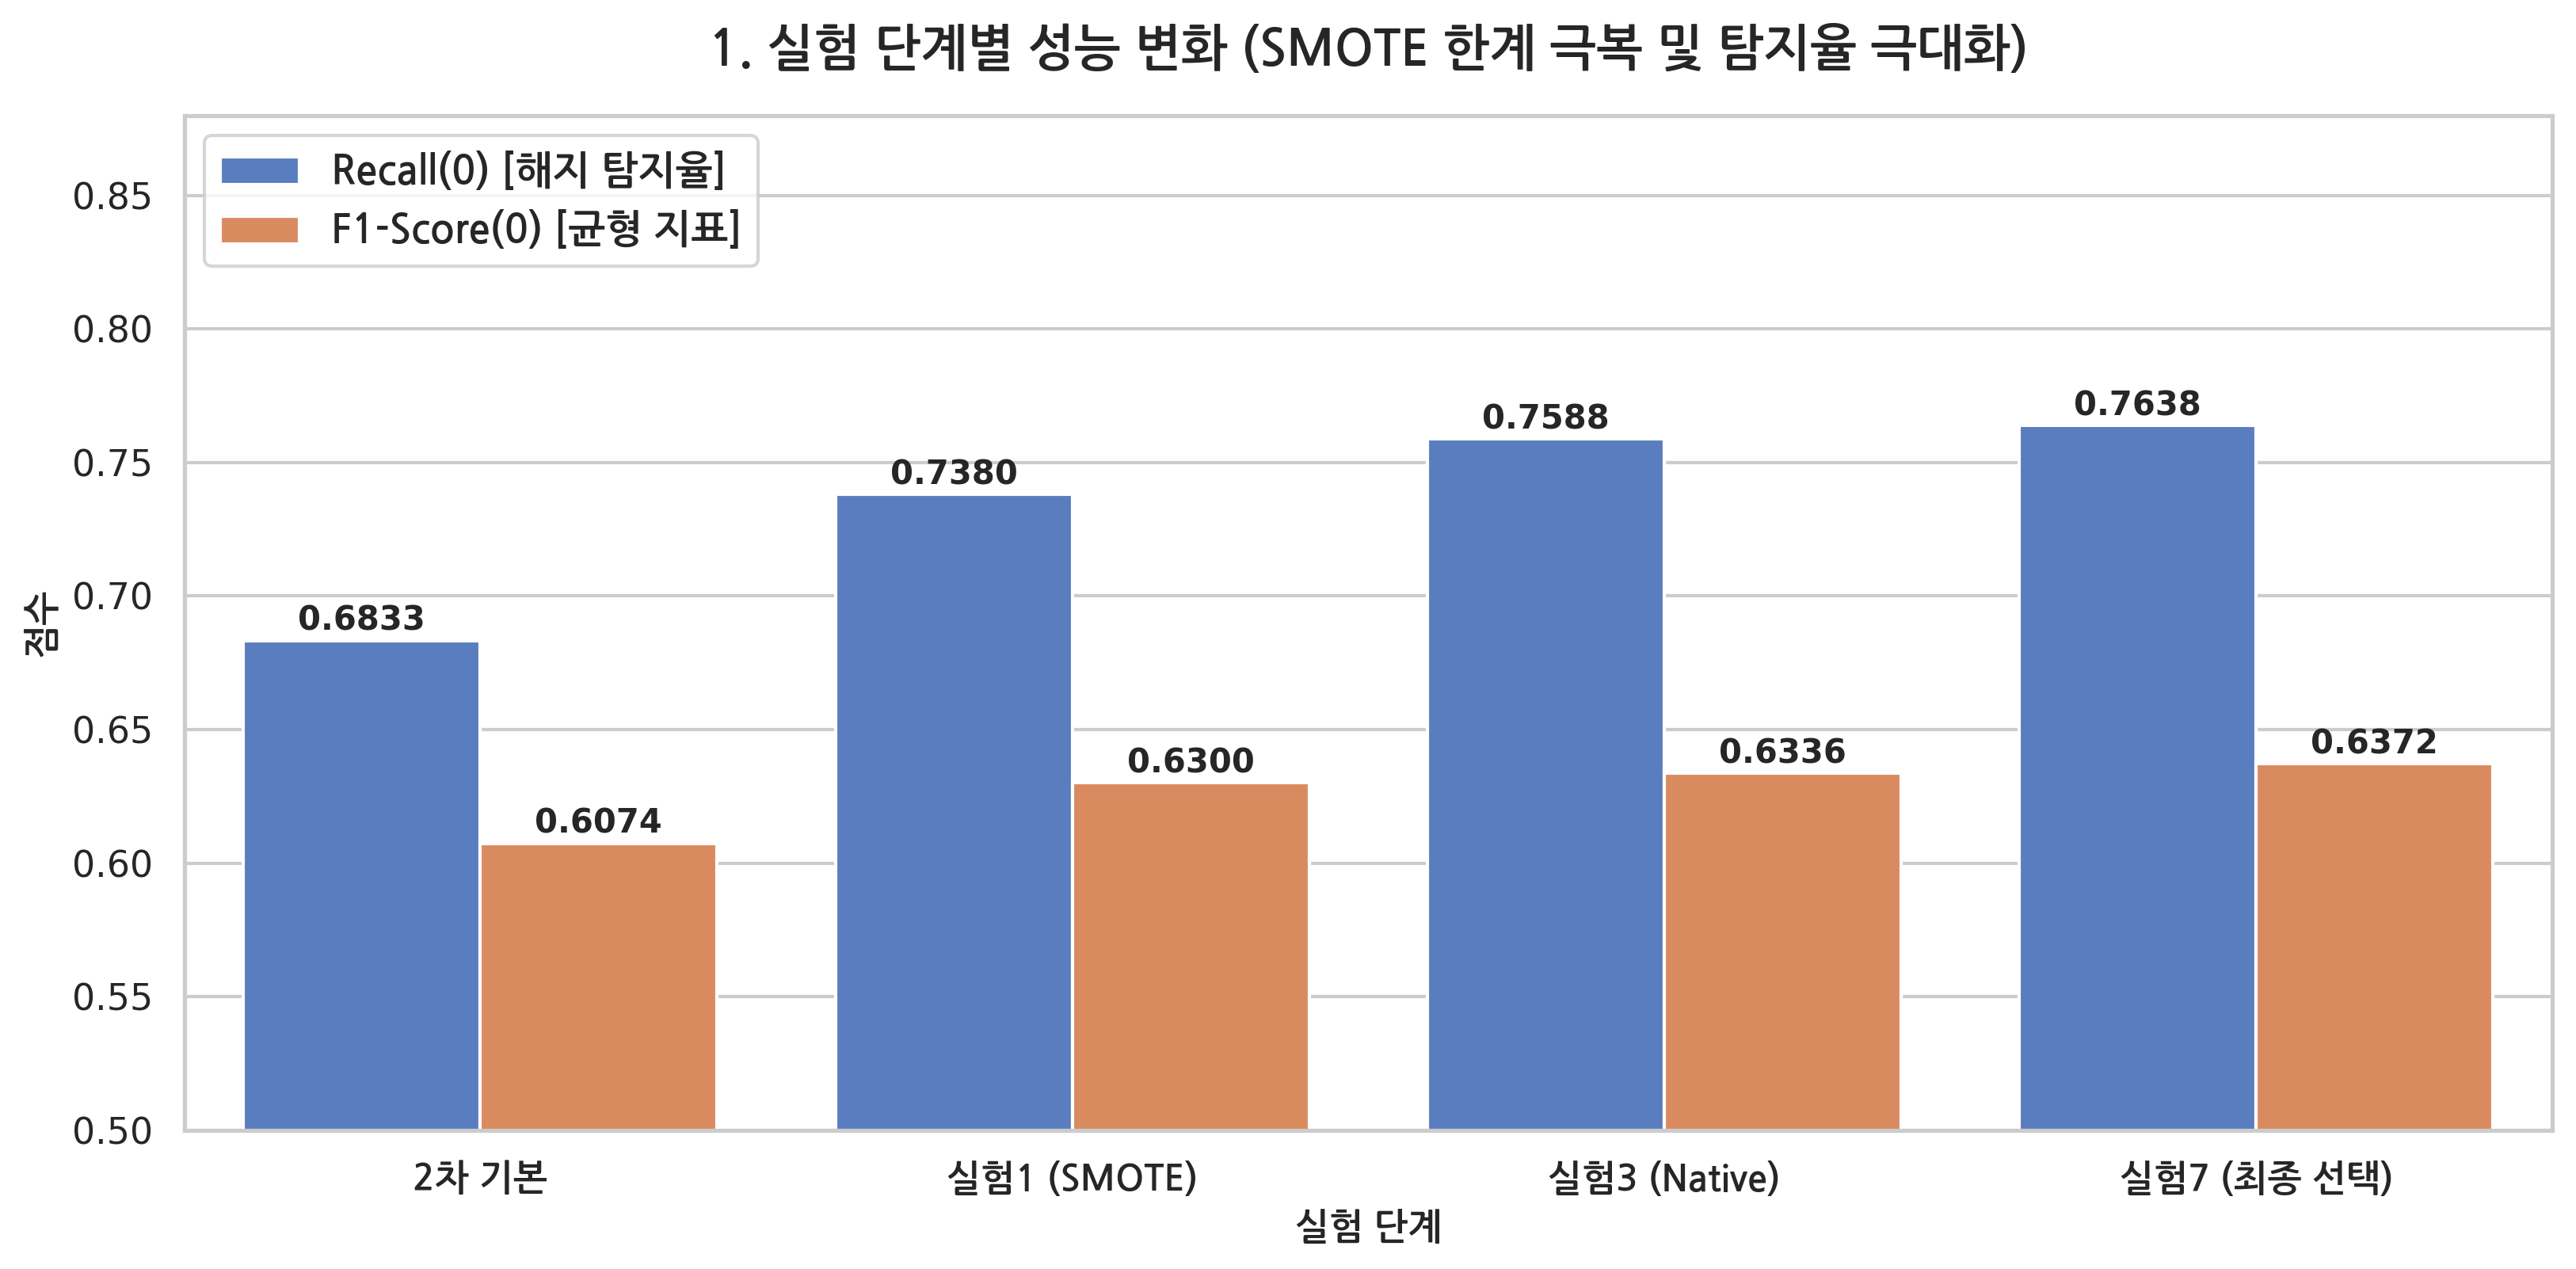

In [20]:
plt.figure(figsize=(11, 5.5), dpi=300) # 고해상도 지정

# 보고서(submission3.md) 실측 데이터 정확히 반영
exp_data = {
    '실험 단계': ['2차 기본', '실험1 (SMOTE)', '실험3 (Native)', '실험7 (최종 선택)'],
    'Recall(0) [해지 탐지율]': [0.6833, 0.7380, 0.7588, 0.7638],
    'F1-Score(0) [균형 지표]': [0.6074, 0.6300, 0.6336, 0.6372]
}
df_exp = pd.DataFrame(exp_data)
df_melted = df_exp.melt(id_vars='실험 단계', var_name='평가 지표', value_name='점수')

ax1 = sns.barplot(data=df_melted, x='실험 단계', y='점수', hue='평가 지표', palette='muted')

plt.title('1. 실험 단계별 성능 변화 (SMOTE 한계 극복 및 탐지율 극대화)', fontproperties=f_prop, fontsize=15, fontweight='bold', pad=15)
plt.xlabel('실험 단계', fontproperties=f_prop, fontsize=11)
plt.ylabel('점수', fontproperties=f_prop, fontsize=11)
plt.ylim(0.5, 0.88)

# X축 레이블 서체 지정
for label in ax1.get_xticklabels():
    label.set_fontproperties(f_prop)
    label.set_fontsize(11)

plt.legend(prop=f_prop, loc='upper left')

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

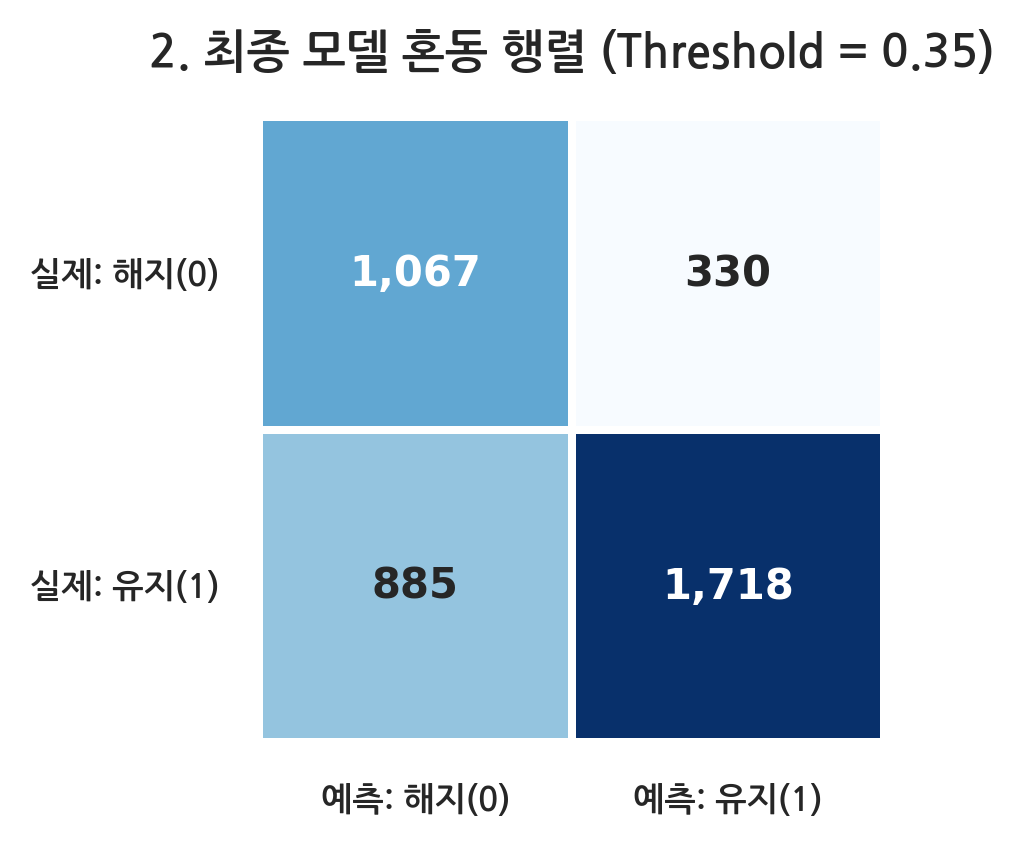

In [21]:
# 한눈에 쏙 들어오는 미니 규격(3.2인치)과 고해상도 유지
plt.figure(figsize=(3.2, 3.2), dpi=300)

# 보고서 7-1 단락의 혼동행렬 실측 데이터 세팅
cm_report = np.array([[1067, 330], [885, 1718]]) #

ax2 = sns.heatmap(cm_report, annot=True, fmt=',d', cmap='Blues', cbar=False, square=True, linewidths=1.5, linecolor='white',
            xticklabels=['예측: 해지(0)', '예측: 유지(1)'],
            yticklabels=['실제: 해지(0)', '실제: 유지(1)'],
            annot_kws={"size": 10, "weight": "bold"})

plt.title('2. 최종 모델 혼동 행렬 (Threshold = 0.35)', fontproperties=f_prop, fontsize=11, fontweight='bold', pad=12)

for label in ax2.get_xticklabels():
    label.set_fontproperties(f_prop)
    label.set_fontsize(8)
for label in ax2.get_yticklabels():
    label.set_fontproperties(f_prop)
    label.set_fontsize(8)
    label.set_rotation(0)

plt.tight_layout()
plt.show()

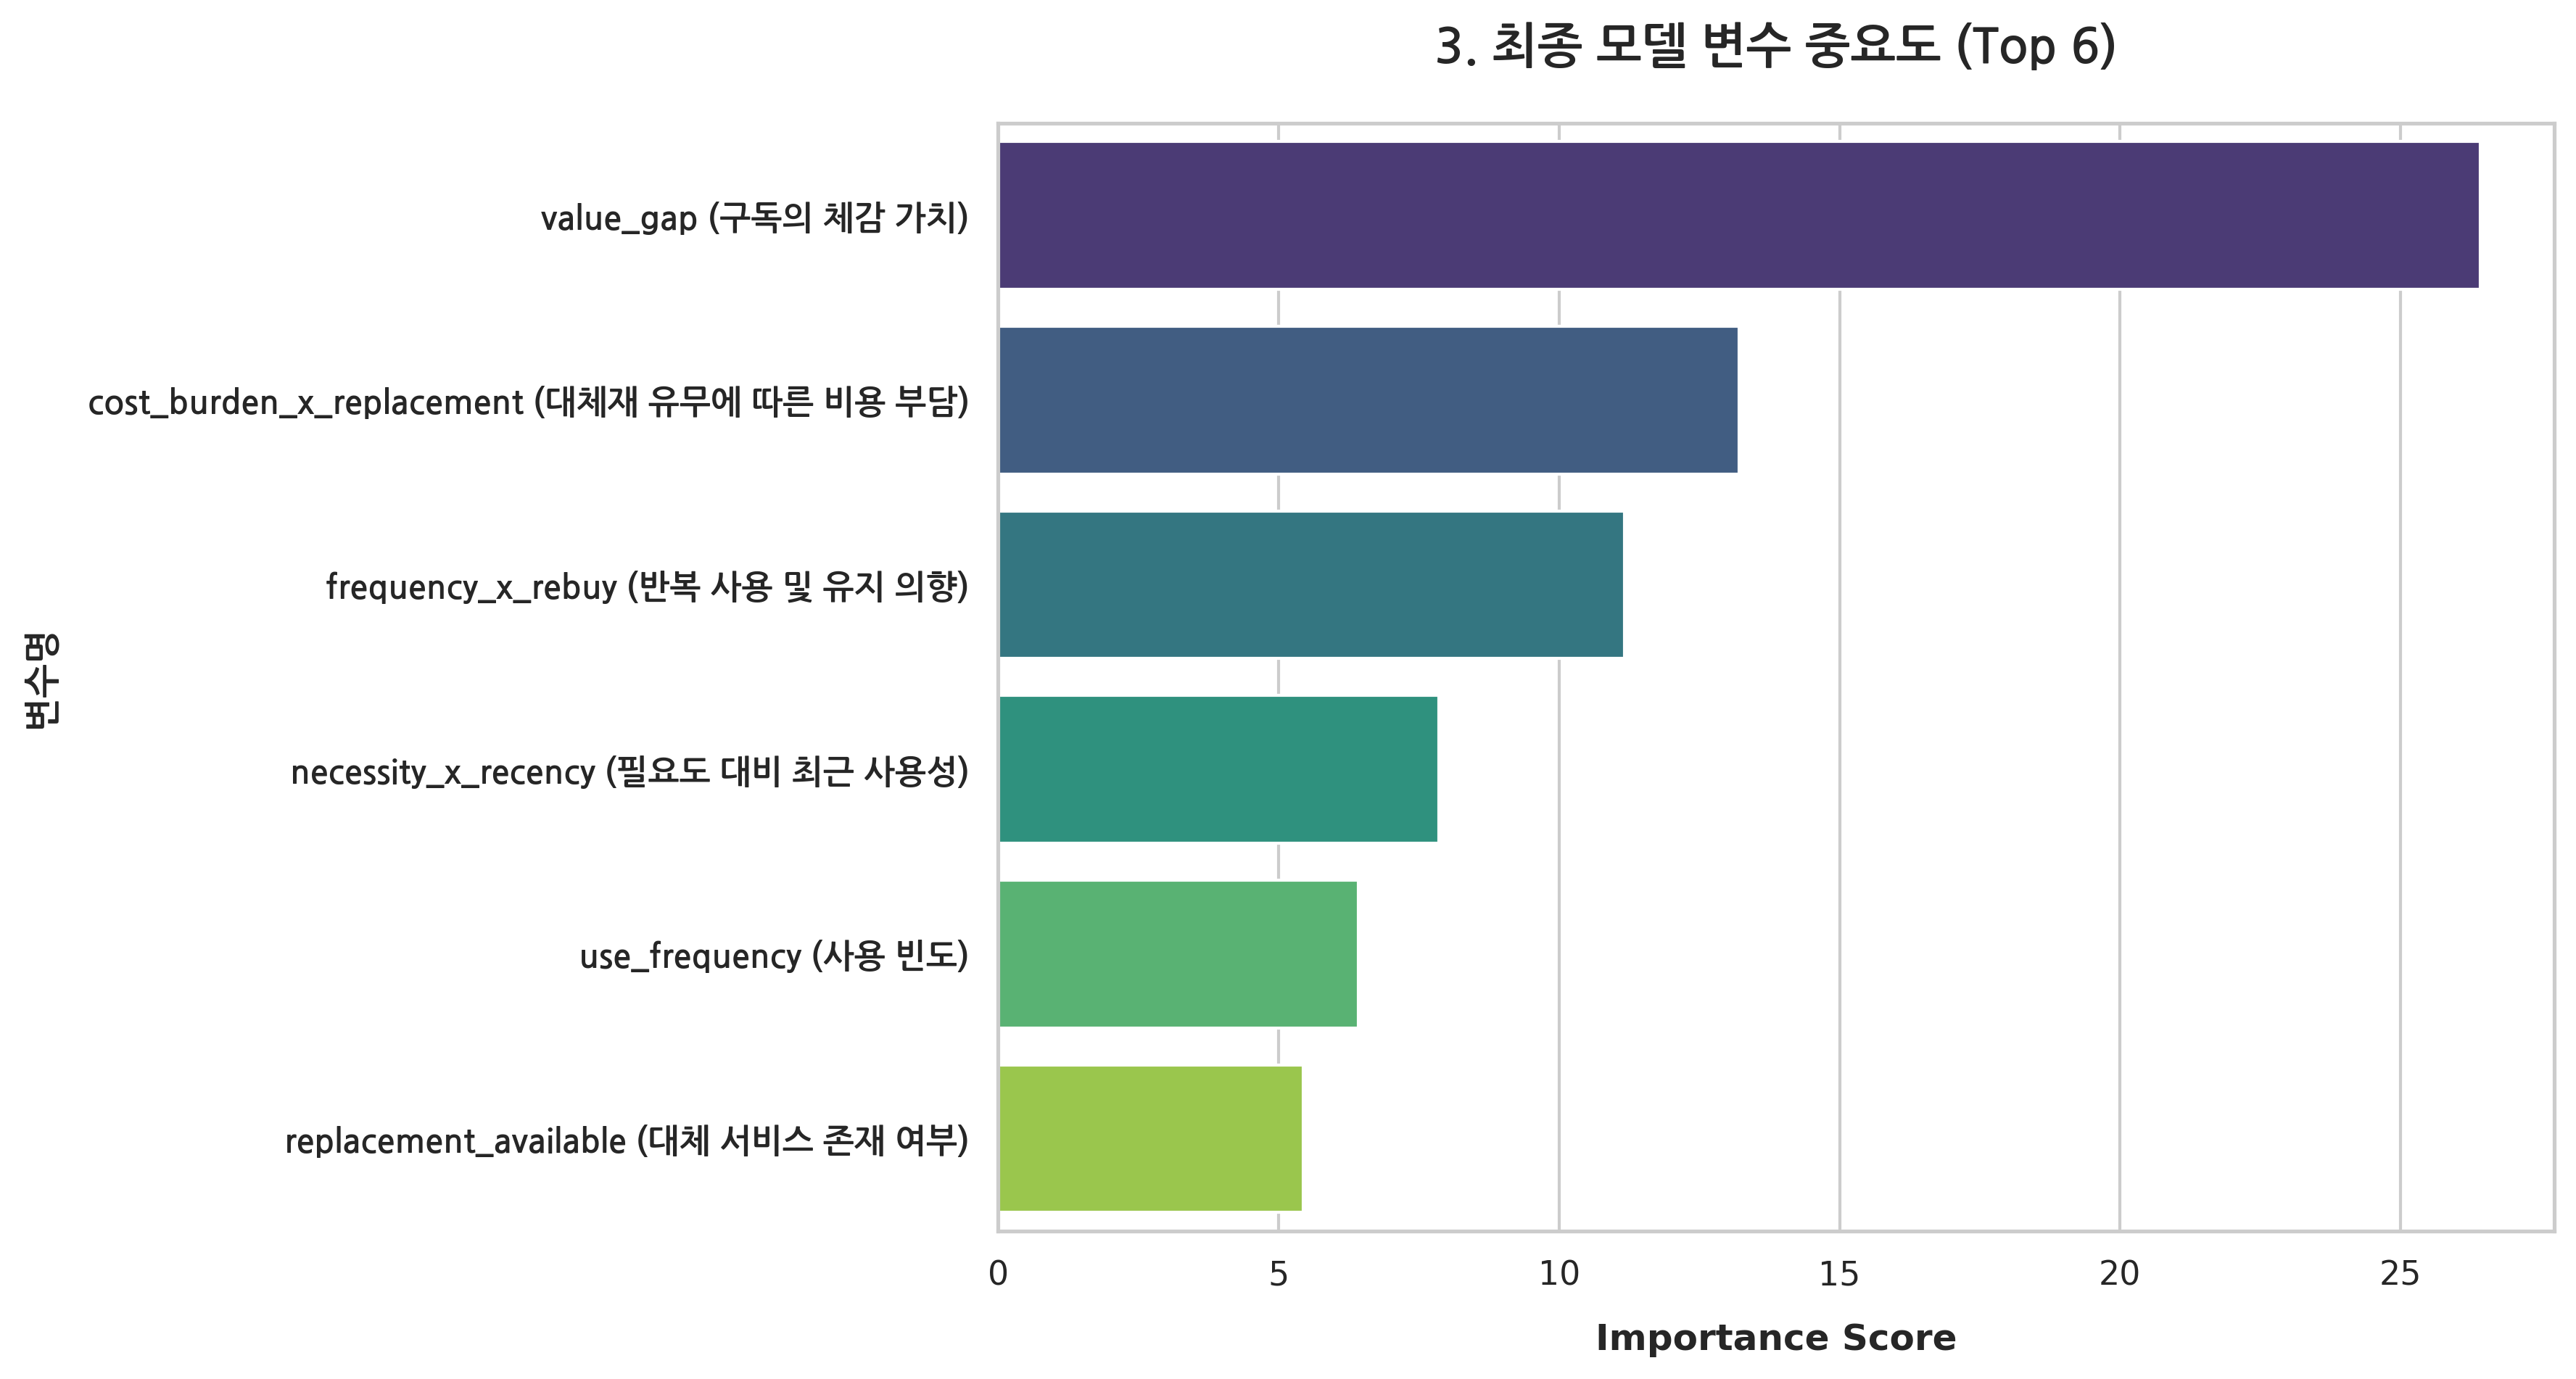

In [22]:
plt.figure(figsize=(12, 6.5), dpi=300)

# 보고서 7-2 단락의 Feature Importance 테이블 수치 오차 없이 그대로 맵핑
feat_imp = {
    '변수명': [
        'value_gap (구독의 체감 가치)',
        'cost_burden_x_replacement (대체재 유무에 따른 비용 부담)',
        'frequency_x_rebuy (반복 사용 및 유지 의향)',
        'necessity_x_recency (필요도 대비 최근 사용성)',
        'use_frequency (사용 빈도)',
        'replacement_available (대체 서비스 존재 여부)'
    ],
    '중요도': [26.42, 13.21, 11.17, 7.85, 6.42, 5.44] # 보고서 실측 수치
}
df_importance = pd.DataFrame(feat_imp).sort_values(by='중요도', ascending=False)

ax3 = sns.barplot(data=df_importance, x='중요도', y='변수명', palette='viridis')

plt.title('3. 최종 모델 변수 중요도 (Top 6)', fontproperties=f_prop, fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('변수명', fontproperties=f_prop, fontsize=12, labelpad=10)

for label in ax3.get_yticklabels():
    label.set_fontproperties(f_prop)
    label.set_fontsize(11)

plt.tight_layout()
plt.show()